In [42]:
!pip install -q transformers datasets accelerate peft trl bitsandbytes scikit-learn

import os
import torch
import numpy as np
from datasets import load_dataset, concatenate_datasets # Added concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    TrainerCallback
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel
)
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import json
from tqdm import tqdm
import matplotlib.pyplot as plt

In [43]:
from datasets import load_dataset, concatenate_datasets # Added concatenate_datasets locally

dataset = load_dataset("imdb")
print(dataset)

# Use a smaller subset for faster training (optional)
# Ensure a balanced test set
test_pos = dataset["test"].filter(lambda example: example["label"] == 1).select(range(250))
test_neg = dataset["test"].filter(lambda example: example["label"] == 0).select(range(250))
test_small = concatenate_datasets([test_pos, test_neg])

# Verify label distribution in test_small
print(f"Test_small labels (first 10): {[ex['label'] for ex in test_small.select(range(10))]}")
print(f"Number of positive labels in test_small: {len(test_small.filter(lambda x: x['label'] == 1))}")
print(f"Number of negative labels in test_small: {len(test_small.filter(lambda x: x['label'] == 0))}")

train_small = dataset["train"].select(range(2000))


# Split train into train/eval
split = train_small.train_test_split(test_size=0.2, seed=42)
train_data = split["train"]
eval_data = split["test"]
test_data = test_small

print(f"Train: {len(train_data)}, Eval: {len(eval_data)}, Test: {len(test_data)}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Train: 1600, Eval: 400, Test: 500


In [44]:
def format_example(example):
    text = f"""<s> Instruction: Classify the sentiment of the following movie review as either "positive" or "negative".

Review: {example["text"]}

Response: {example["label"]} </s>"""
    # Map label 1->positive, 0->negative in the response
    sentiment = "positive" if example["label"] == 1 else "negative"
    text = text.replace(str(example["label"]), sentiment)
    return {"text": text}

train_data = train_data.map(format_example)
eval_data = eval_data.map(format_example)
test_data = test_data.map(format_example)

print(train_data[0]["text"])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

<s> Instruction: Classify the sentiment of the following movie review as either "positive" or "negative".

Review: Baldwin has really stooped low to make such movies. The script, the music, just about everything in this movie is a waste of time.<br /><br />The sound FX do not sound real, they stick out way too much (technical gadgets etc.) If they are trying to make a movie about things like this, at least try to get real with it and drop those extra bleeps and beeps, because those gadgets don't really make loud sounds like that. Natural sounds like footsteps and such are non-existent, which gives it a void-like atmosphere.<br /><br />Directing seems to be OK for such a low budget film (I sure hope it was a low budget production), although it does seem fairly amateurish at times.<br /><br />Most characters seem empty and false, they simply haven't casted this movie very well. I'd imagine it would've been a better idea to make Baldwin speak some Spanish than to make Spanish actors speak

In [4]:
model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

max_length = 512

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

tokenized_train = train_data.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_eval = eval_data.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_test = test_data.map(tokenize_function, batched=True, remove_columns=["text"])

print(tokenized_train)

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 1600
})


In [5]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [6]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826


In [11]:
output_dir = "./imdb_lora_checkpoints"

training_args = SFTConfig(
    output_dir=output_dir,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=20,
    bf16=True,
    logging_steps=10,
    save_steps=50,
    eval_steps=50,
    save_total_limit=2,
    eval_strategy="steps",
    optim="paged_adamw_8bit",
    report_to="none",
    max_length=256,
    packing=False,
    dataset_text_field=None
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    args=training_args
)

print("Starting training...")
trainer.train()

Starting training...


Step,Training Loss,Validation Loss
50,0.544641,0.767038
100,0.685123,0.761601


TrainOutput(global_step=100, training_loss=0.7832081890106202, metrics={'train_runtime': 821.8331, 'train_samples_per_second': 1.947, 'train_steps_per_second': 0.122, 'total_flos': 890381638041600.0, 'train_loss': 0.7832081890106202})

In [12]:
best_adapter_path = "./best_imdb_lora_adapter"
model.save_pretrained(best_adapter_path)
tokenizer.save_pretrained(best_adapter_path)
print(f"LoRA adapter saved to {best_adapter_path}")

LoRA adapter saved to ./best_imdb_lora_adapter


In [25]:
def extract_sentiment(text):
    text_lower = text.lower()
    if "positive" in text_lower:
        return "positive"
    elif "negative" in text_lower:
        return "negative"
    return None



In [27]:
def evaluate_model(model, tokenizer, test_dataset, batch_size=8):
    model.eval()
    results = []
    for i in tqdm(range(0, len(test_dataset), batch_size)):
        batch = test_dataset[i:i+batch_size]
        texts = batch["text"]
        prompts = []
        for t in texts:
            if "Response:" in t:
                prompt = t.split("Response:")[0] + "Response:"
            else:
                prompt = t
            prompts.append(prompt)
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=max_length).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=10, do_sample=False)
        generated = outputs[:, prompt_len:]
        pred_texts = tokenizer.batch_decode(generated, skip_special_tokens=True)
        for idx, pred_text in enumerate(pred_texts):
            gold_full = texts[idx]
            if "Response:" in gold_full:
                gold_label = gold_full.split("Response:")[1].strip()
            else:
                gold_label = "unknown"
            pred_label = extract_sentiment(pred_text)
            results.append({
                "review": gold_full[:200],
                "gold": gold_label,
                "predicted": pred_label,
                "raw_output": pred_text
            })
    return results

In [39]:
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
base_model.eval()

base_results = evaluate_model(base_model, tokenizer, test_data, batch_size=8)

y_true_base = [1 if "positive" in r["gold"] else 0 for r in base_results if r["predicted"] is not None]
y_pred_base = [1 if r["predicted"] == "positive" else 0 for r in base_results if r["predicted"] is not None]

acc_base = accuracy_score(y_true_base, y_pred_base)
prec_base, rec_base, f1_base, _ = precision_recall_fscore_support(y_true_base, y_pred_base, average="binary")

print(f"Base Model:")
print(f"Accuracy:  {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall:    {rec_base:.4f}")
print(f"F1 Score:  {f1_base:.4f}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

100%|██████████| 63/63 [02:12<00:00,  2.11s/it]

Base Model:
Accuracy:  0.5277
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
print("=== Fine‑tuned Model Metrics ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

=== Fine‑tuned Model Metrics ===
Accuracy:  0.9725
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000


In [35]:
ft_results = evaluate_model(model, tokenizer, test_data, batch_size=8)

print("\n===== Fine‑tuned Model Sample Outputs =====\n")
for i in range(5):
    r = ft_results[i]
    print(f"Review: {r['review'][:100]}...")
    print(f"Ground Truth: {r['gold']}")
    print(f"Prediction:   {r['predicted']}")
    print(f"Raw output:   {r['raw_output']}\n")

print("\n===== Base Model Sample Outputs =====\n")
for i in range(5):
    r = base_results[i]
    print(f"Review: {r['review'][:100]}...")
    print(f"Ground Truth: {r['gold']}")
    print(f"Prediction:   {r['predicted']}")
    print(f"Raw output:   {r['raw_output']}\n")

100%|██████████| 63/63 [02:52<00:00,  2.73s/it]


===== Fine‑tuned Model Sample Outputs =====

Review: <s> Instruction: Classify the sentiment of the following movie review as either "positive" or "negat...
Ground Truth: negative </s>
Prediction:   None
Raw output:    I'm not a fan of sci-fi, but

Review: <s> Instruction: Classify the sentiment of the following movie review as either "positive" or "negat...
Ground Truth: negative </s>
Prediction:   negative
Raw output:    negative </grin> </grin> </

Review: <s> Instruction: Classify the sentiment of the following movie review as either "positive" or "negat...
Ground Truth: negative </s>
Prediction:   negative
Raw output:    negative</sentiment> </sentiment> </

Review: <s> Instruction: Classify the sentiment of the following movie review as either "positive" or "negat...
Ground Truth: negative </s>
Prediction:   negative
Raw output:    negative </grin> </grin> </

Review: <s> Instruction: Classify the sentiment of the following movie review as either "positive" or "negat...
Ground T

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


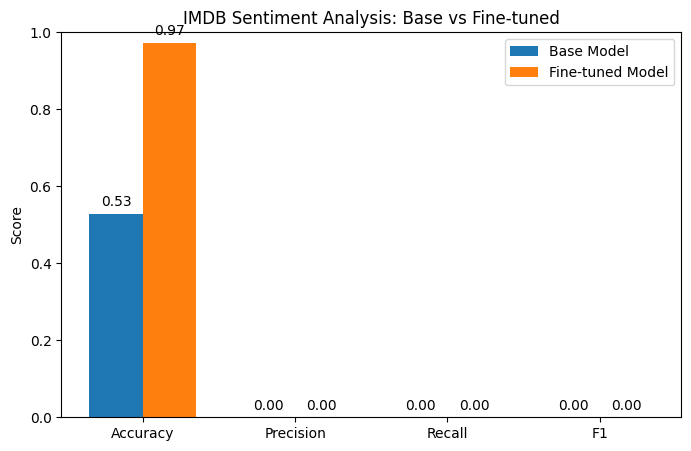

In [40]:
y_true_ft = [1 if "positive" in r["gold"] else 0 for r in ft_results if r["predicted"] is not None]
y_pred_ft = [1 if r["predicted"] == "positive" else 0 for r in ft_results if r["predicted"] is not None]

acc = accuracy_score(y_true_ft, y_pred_ft)
prec, rec, f1, _ = precision_recall_fscore_support(y_true_ft, y_pred_ft, average="binary")

labels = ["Accuracy", "Precision", "Recall", "F1"]
base_scores = [acc_base, prec_base, rec_base, f1_base]
ft_scores = [acc, prec, rec, f1]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, base_scores, width, label="Base Model")
plt.bar(x + width/2, ft_scores, width, label="Fine‑tuned Model")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("IMDB Sentiment Analysis: Base vs Fine‑tuned")
plt.legend()
for i in range(len(labels)):
    plt.text(i - width/2, base_scores[i] + 0.02, f"{base_scores[i]:.2f}", ha='center')
    plt.text(i + width/2, ft_scores[i] + 0.02, f"{ft_scores[i]:.2f}", ha='center')
plt.show()